### [The spelled-out intro to neural networks and backpropagation: building micrograd](https://www.youtube.com/watch?v=VMj-3S1tku0&t=3356s)

### [chatGPT-4, released on 2023-03-14, has 1 trillion paramaters and cost $100 million to train](https://en.wikipedia.org/wiki/GPT-4)

In [36]:
import math, random, torch
import numpy as np
# import random
import matplotlib.pyplot as plt
%matplotlib inline

In [37]:
# verbose = True   # print calculation output and weights and bias matrices
verbose = False  # print calculation output only

In [38]:
def plot_losses(losses):
    # import matplotlib.pyplot as plt

    # Create a list of iterations
    iterations = range(len(losses))

    # Plot the loss as a function of iteration
    plt.plot(iterations, losses)

    # Add a title to the plot
    plt.title("Loss vs. Iteration")

    # Add labels to the x-axis and y-axis
    plt.xlabel("Iteration")
    plt.ylabel("Loss")

In [39]:
def print_parameters(parameters):
    # number of parameters (e.g sum (weights + bias to each neuron and output))
    # MLP(3, [4, 4, 1]) --> 4_neurons(3_inputs + 1_bias) + 4_neurons(4_neurons + 1_bias) + 1_output(4_neurons + 1_bias) = 41_parameters
    # print(f'Number of parameters in MLP(2, [3, 3, 1]): {len(parameters())}\n')
    print(f"Total parameters: {len(parameters())}\n")

    # print first 5 parameters
    for i, v in enumerate(parameters()):
        if i < 5:
            print(f"i: {i:>2}, {v.data:>14.10f}")

    print("---")

    # print last 5 parameters
    for i, v in enumerate(parameters()):
        if i >= len(parameters()) - 5:
            print(f"i: {i:>2}, {v.data:>14.10f}")

In [40]:
def get_wt_n_b_mats(layers, verbose=False):
    """Get neuron's weights and bias for each layer.
    Inputs: If n = MLP(2, [3, 3, 1]), input is n.layers.

    return: two lists of np.arrays. The first list is weight matrix for each layer
            The second list is the bias matrix for each layer
    """
    layer_cnt = len(layers)  # number of layers
    w_mats = []  # list of weights matrix for each layer
    b_mats = []  # list of bias matrix for each layer
    if verbose:
        print(f"layer_cnt: {layer_cnt}\n")
    for i, layer in enumerate(layers):
        neuron_cnt = len(layer.neurons)  # numbers of neurons in the layer
        if verbose:
            print(f"layer: {i}, neuron_cnt: {neuron_cnt}")

            print("----")
        b_mat = []  # accumulate neuon's bias for each row
        for j, neuron in enumerate(layer.neurons):
            if verbose:
                print(f"layer: {i}, neuron {j}")
            b = neuron.b.data  # bias of neuron
            w_row = []  # accumulate neuon's weights for each row
            b_row = []  # accumulate neuon's bias for each row
            for k, w in enumerate(neuron.w):
                w_row.append(w.data)
                if verbose:
                    print(f"w{k}: {w.data:10.7f},   w{k}.grad: {w.grad:10.7f}")
            if j == 0:
                w_mat = np.array([w_row])
            else:
                w_mat = np.vstack((w_mat, w_row))

            b_mat.append(b)
            if verbose:
                print(f"b:  {b:10.7f}\n")
                print(f"b:  {b:10.7f}")
                print(f"b_mat:  {b_mat}\n")
        w_mats.append(w_mat)
        b_mats.append(np.array([b_mat]))
        if verbose:
            print("------")

    zipped_w_n_b = zip(w_mats, b_mats)
    if verbose:
        for i, w_n_b in enumerate(zipped_w_n_b):
            print(f"layer: {i}")  # 1st layer is 0
            print(f"w_mat{w_n_b[0].shape}:\n{w_n_b[0]}")
            print(f"b_mat{w_n_b[1].shape}:\n{w_n_b[1]}\n")

    return w_mats, b_mats

In [41]:
def forward_pass(layers, verbose=verbose):
    # Get Neural Network's Weights and Biases Matrices
    # w_mats, b_mats = get_wt_n_b_mats(n.layers, verbose=verbose)
    w_mats, b_mats = get_wt_n_b_mats(layers, verbose=verbose)

    # Calculate Neural Network Output and Loss with Matrix Multiplication
    for layer in range(len(layers)):
        if layer == 0:  # first layer, use given inputs xs as inputs
            input = xs_mats_T[layer]
        else:  # after first layer, use outputs from preceding layers as inputs
            input = output

        weights = w_mats[layer]
        bias = np.transpose(b_mats[layer])

        weights_x_input = np.matmul(weights, input)
        weights_x_input_plus_bias = weights_x_input + bias

        # output = np.tanh(np.matmul(weights, input) + bias)
        output = np.tanh(weights_x_input_plus_bias)

        print(f'{"-"*50}')
        print(f"Calculate Output of Layer: {layer}")
        print(f"weights {weights.shape}:\n{weights}\n")
        print(f"input {input.shape}:\n{input}\n")

        print(f"weights_x_inputs {weights_x_input.shape}:\n{weights_x_input}\n")
        print(f"bias {bias.shape}:\n{bias}\n")
        print(
            f"weights_x_inputs_+_bias {weights_x_input_plus_bias.shape}:\n{weights_x_input_plus_bias}\n"
        )

        # print(f'output = tanh(weights_x_inputs_+_bias) {output.shape}:\n{output}\n')
        print(
            f"Layer {layer} Output = tanh(weights_x_inputs_+_bias) {output.shape}:\n{output}\n"
        )

    yout = output[0]
    err = yout - ys
    err_sq = err**2
    loss_sum = err_sq.sum()
    loss_mean = err_sq.mean()

    # print(f'-- Manual calculation results of neural network output and prediction error --')
    print(f"-- Results of neural network outputs and Loss --")
    print(f"yout:           {yout}")
    print(f"desired output: {ys}")
    print(f"err:            {err}")
    print(f"err_sq:         {err_sq}")
    print(f"loss_sum:       {loss_sum}")
    print(f"loss_mean:      {loss_mean}")

    return yout, err, err_sq, loss_sum, loss_mean, w_mats, b_mats

### Micrograd Classes and Functions<br>* limited to neural network with one output, e.g. MLP(2, [3, 1])<br>* neural network with multiple outputs, e.g.  MLP(2, [3, 3]), will produce errors in backward pass 

In [42]:
from graphviz import Digraph


def trace(root):
    """Builds a set of all nodes and edges in a graph."""
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    """Creates a Digraph representation of the graph."""
    dot = Digraph(format="svg", graph_attr={"rankdir": "LR"})  # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # For any value in the graph, create a rectangular ('record') node for it.
        dot.node(
            name=uid,
            label="{ %s | data %.4f | grad % .4f }" % (n.label, n.data, n.grad),
            shape="record",
        )

        if n._op:
            # If this value is a result of some operation, create an op node.
            dot.node(name=uid + n._op, label=n._op)
            # And connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # Connect nl to the op node of n2.
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [43]:
class Value:

    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self) -> str:
        return f"Value(data = {self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward

        return out

    def __radd__(self, other):  # other + self
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward

        return out

    def __rmul__(self, other):  # other * self
        return self * other

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only support int/float power for now"
        out = Value(self.data**other, (self,), f"**{other}")

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad

        out._backward = _backward

        return out

    def __truediv__(self, other):  # self / other
        return self * other**-1

    def __neg__(self):  # -self
        return self * -1

    def __sub__(self, other):  # self - other
        return self + (-other)

    def __rsub__(self, other):  # other - self
        return other + (-self)

    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(t, (self,), "tanh")

        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward

        return out

    # https://en.wikipedia.org/wiki/Hyperbolic_functions
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), "exp")

        def _backward():
            self.grad += out.data * out.grad

        out._backward = _backward

        return out

    def backward(self):
        topo = []
        visited = set()

        # topological sort
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)

        self.grad = 1  # initialize
        for node in reversed(topo):
            node._backward()

In [44]:
class Neuron:

    def __init__(self, nin):
        # random numbers evenly distributed between -1 and 1
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    #### my add ##########################################
    def __repr__(self) -> str:
        return f"Neuron(w = {self.w}, b = {self.b})"

    ######################################################

    def __call__(self, x):
        # w * x + b
        # print(list(zip(self.w, x)), self.b)
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        # print(f'w: {self.w}, b: {[self.b]}')
        return self.w + [self.b]


class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    #### my add ##########################################
    def __repr__(self) -> str:
        return f"Layer(neurons = {self.neurons})"

    ######################################################

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        # params = []
        # for neuron in self.neurons:
        #     ps = neuron.parameters()
        #     params.extend(ps)
        # return params
        return [p for neuron in self.neurons for p in neuron.parameters()]


class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        params = []
        # for layer in self.layers:
        #     ps = layer.parameters()
        #     params.extend(ps)
        # return params
        return [p for layer in self.layers for p in layer.parameters()]

#   &nbsp;
# - Human Brain and Artificial Neural Network - 

### Neurons in Human Brain
![](..\karpathy\img\neuron_of_human_brain.png)

### Artificial Neuron Function

<img src="..\karpathy\img\Artificial Neuron Function.png">

### Simple Artificial Neural Network<br>* input layer: &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; 2 nodes<br>* hidden layer 1: &nbsp;3 nodes<br>* hidden layer 2:&nbsp;&nbsp;3 nodes<br>*  output layer: &nbsp;&nbsp;&nbsp; 1 node<br>* node's bias and activation function are not shown

<!-- ![Getting Started](..\karpathy\img\Nertual_Network_Neuron.PNG) -->
<img src="..\karpathy\img\MLP (2, [3, 3, 1]).png">

# &nbsp;
# - Visualize Math Operations in a Hidden Layer -

### * Assume hidden layer with two inputs (X0, X1), and three neurons (b0, b1, b2)<br>* Two sets of inputs (X0, X1) are shown in different shades of gray<br>* Two sets of outputs (Y0, Y1, Y2) are shown in corresponding shades of gray<br>* Both sets of inputs are processed in one matrix operation 

<img src="..\karpathy\img\Hidden Layer Matrix Operations.png">

# &nbsp;
# - Create Simple Neural Network with Micrograd -
##### MLP(2, [3, 3, 1])<br>* 2 input nodes<br>* 3 neurons in hidden layer 1<br>* 3 neurons in hidden layer 2<br>* 1 output node
##### Initialize Neurons Parameters <br>* parameters in layer 1: 3 neurons * (2 inputs + 1 bias) = &nbsp;&nbsp;&nbsp;&nbsp;  9<br>* parameters in layer 2: 3 neurons * (3 neurons + 1 bias) = 12<br>* parameters in layer 3: 1 output * (3 neurons + 1 bias) = &nbsp;&nbsp;&nbsp; 4<br>*  total parameters: 25

In [45]:
# create neural network and initialize weights and biases
n = MLP(2, [3, 3, 1])

# if verbose:
if True:
    print("Neuron parameters, initialized with random numbers")
    print_parameters(n.parameters)

Neuron parameters, initialized with random numbers
Total parameters: 25

i:  0,   0.2254331442
i:  1,  -0.3431568652
i:  2,   0.7233275892
i:  3,   0.3241694317
i:  4,   0.1048180101
---
i: 20,   0.6910725129
i: 21,   0.5303097972
i: 22,   0.9178324624
i: 23,   0.7575229133
i: 24,   0.7349659026


# &nbsp;
# - Set Inputs, Desired Outputs, Learning Rate -
##### Inputs<br>* 1st set: [2.0, 1.0]<br>* 2nd set: [3.0, -2.0]
##### Desired Outputs<br>* [1.0, -1.0] for all input sets
##### Learning Rate<br>* 0.05

In [46]:
# inputs
xs = [[2.0, 1.0], [3.0, -2.0]]

# desired targets
ys = [1.0, -1.0]

# learning rate (i.e. step size)
learning_rate = 0.05

In [47]:
# if verbose:
if True:
    # print weights and bias of each layer
    print(f"neurons' weights and bias of each layer")
    for i, layer in enumerate(n.layers):
        neuron_cnt = len(layer.neurons)  # numbers of neurons in the layer
        print(f"layer: {i}, neuron_cnt: {neuron_cnt}, layer: {layer}")

neurons' weights and bias of each layer
layer: 0, neuron_cnt: 3, layer: Layer(neurons = [Neuron(w = [Value(data = 0.2254331441929569), Value(data = -0.3431568652026844)], b = Value(data = 0.7233275891944488)), Neuron(w = [Value(data = 0.3241694317388524), Value(data = 0.10481801006795122)], b = Value(data = 0.8262920846035173)), Neuron(w = [Value(data = -0.16003328378190673), Value(data = 0.2482066933248297)], b = Value(data = -0.7872267197287348))])
layer: 1, neuron_cnt: 3, layer: Layer(neurons = [Neuron(w = [Value(data = 0.8099966934985541), Value(data = 0.4917733211877371), Value(data = 0.26926415268219106)], b = Value(data = -0.3737440484819876)), Neuron(w = [Value(data = -0.4809386746662012), Value(data = 0.5354929093821355), Value(data = 0.675635835437038)], b = Value(data = -0.36407557600803364)), Neuron(w = [Value(data = -0.2144646643890722), Value(data = 0.8739289838268454), Value(data = 0.9823825542244911)], b = Value(data = 0.6910725129497883))])
layer: 2, neuron_cnt: 1, lay

# &nbsp;
# - Calculate Neural Network Outputs and Loss (i.e. Prediction Errors) -
##### * transpose inputs<br>* select activation function<br>* calculate outputs, (a.k.a) Forward Pass<br>* calculate Loss

##### Transpose Inputs

In [48]:
xs_mats = [np.array(xs)]  # convert xs to list of np.arrays
xs_mats_T = []
for mat in xs_mats:
    mat_transpose = np.transpose(mat)
    xs_mats_T.append(mat_transpose)

print(f"xs_mats[0].shape: {xs_mats[0].shape}")
print(f"xs_mats:\n{xs_mats}\n")
print(f"xs_mats_T[0].shape: {xs_mats_T[0].shape}")
print(f"xs_mats_T:\n{xs_mats_T}")

xs_mats[0].shape: (2, 2)
xs_mats:
[array([[ 2.,  1.],
       [ 3., -2.]])]

xs_mats_T[0].shape: (2, 2)
xs_mats_T:
[array([[ 2.,  3.],
       [ 1., -2.]])]


##### Common Activation Functions

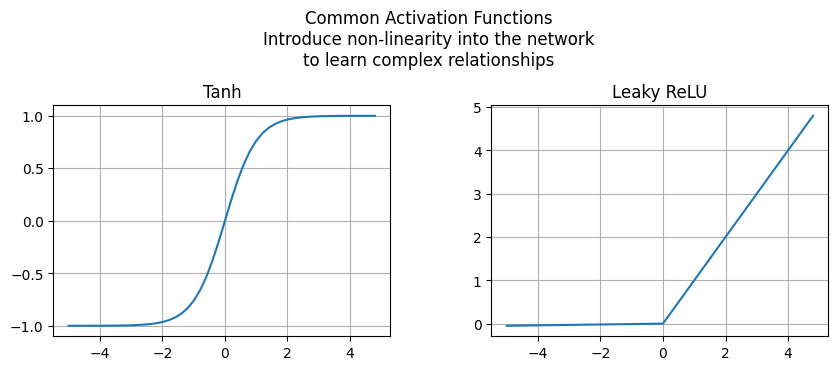

In [49]:
# Common Activation Functions
x = np.arange(-5, 5, 0.2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

ax1.plot(x, np.tanh(x))
ax1.set_title("Tanh")
ax1.grid()

a = x[x < 0] * 0.01
b = x[x >= 0]
y = np.concatenate((a, b))
ax2.grid()
ax2.plot(x, y)
ax2.set_title("Leaky ReLU")

plt_title = "Common Activation Functions\nIntroduce non-linearity into the network\nto learn complex relationships"
plt.suptitle(plt_title, fontsize=12, y=1.2)
plt.subplots_adjust(wspace=0.3)
plt.show()

##### Calculate Outputs and Loss Using Tanh Activation

In [50]:
yout, err, err_sq, loss_sum, loss_mean, w_mats, b_mats = forward_pass(
    n.layers, verbose=verbose
)

--------------------------------------------------
Calculate Output of Layer: 0
weights (3, 2):
[[ 0.22543314 -0.34315687]
 [ 0.32416943  0.10481801]
 [-0.16003328  0.24820669]]

input (2, 2):
[[ 2.  3.]
 [ 1. -2.]]

weights_x_inputs (3, 2):
[[ 0.10770942  1.36261316]
 [ 0.75315687  0.76287228]
 [-0.07185987 -0.97651324]]

bias (3, 1):
[[ 0.72332759]
 [ 0.82629208]
 [-0.78722672]]

weights_x_inputs_+_bias (3, 2):
[[ 0.83103701  2.08594075]
 [ 1.57944896  1.58916436]
 [-0.85908659 -1.76373996]]

Layer 0 Output = tanh(weights_x_inputs_+_bias) (3, 2):
[[ 0.68103244  0.9696221 ]
 [ 0.91851579  0.92002111]
 [-0.69578676 -0.94291925]]

--------------------------------------------------
Calculate Output of Layer: 1
weights (3, 3):
[[ 0.80999669  0.49177332  0.26926415]
 [-0.48093867  0.53549291  0.67563584]
 [-0.21446466  0.87392898  0.98238255]]

input (3, 2):
[[ 0.68103244  0.9696221 ]
 [ 0.91851579  0.92002111]
 [-0.69578676 -0.94291925]]

weights_x_inputs (3, 2):
[[ 0.81598515  0.98393818

In [51]:
print(f"-- Neural network outputs and Loss --")
print(f"yout:           {yout} <-- neural network output")
print(f"desired output: {ys} <-- target")
print(f"err:            {err} <-- prediction_error")
print(f"err_sq:         {err_sq} <-- prediction_error^2")
print(f"loss_sum:       {loss_sum} <-- sum(prediction_error)^2")
print(f"loss_mean:      {loss_mean} <-- mean(prediction_error)^2")

-- Neural network outputs and Loss --
yout:           [0.69559989 0.53458997] <-- neural network output
desired output: [1.0, -1.0] <-- target
err:            [-0.30440011  1.53458997] <-- prediction_error
err_sq:         [0.09265943 2.35496637] <-- prediction_error^2
loss_sum:       2.4476258005754126 <-- sum(prediction_error)^2
loss_mean:      1.2238129002877063 <-- mean(prediction_error)^2


##### Save original parameters

In [52]:
# save original parameters
param_org = [p.data for p in n.parameters()]

#   &nbsp;
# - How Artificial Neural Network Learns -

##### * calculate gradients (i.e. changes in Loss w.r.t. changes in each parameter)<br>* use gradients to adjust parameters in direction of less Loss<br>* repeat the steps

##### Manual gradient calculation for parameter W0<br>* calculate outputs and Loss<br>* increase W0 by small amount, e.g. 0.00001<br>* recalculate outputs and Loss<br>* calculate gradient (W0_grad = changes_in_Loss / changes_in_W0)
##### Increase W0 by small amount

In [53]:
# Increase W0 by h
h = 0.000001
loss_mean_before = loss_mean
print(f"loss_mean before increase Wo:  {loss_mean_before:10.7f}")
W0_before = n.parameters()[0].data  # W1
print(f"W0_before:                     {W0_before:10.7f}")
n.parameters()[0].data += h
W0_after = n.parameters()[0].data
print(f"W0_after:                      {W0_after:10.7f}")
W0_dif = W0_after - W0_before
print(
    f"W0_dif:                        {W0_dif:10.7f} <-- increased W0 by a small amount"
)

loss_mean before increase Wo:   1.2238129
W0_before:                      0.2254331
W0_after:                       0.2254341
W0_dif:                         0.0000010 <-- increased W0 by a small amount


##### Recalculate output and Loss with small changes in W0

In [54]:
yout, err, err_sq, loss_sum, loss_mean, w_mats, b_mats = forward_pass(
    n.layers, verbose=verbose
)

--------------------------------------------------
Calculate Output of Layer: 0
weights (3, 2):
[[ 0.22543414 -0.34315687]
 [ 0.32416943  0.10481801]
 [-0.16003328  0.24820669]]

input (2, 2):
[[ 2.  3.]
 [ 1. -2.]]

weights_x_inputs (3, 2):
[[ 0.10771142  1.36261616]
 [ 0.75315687  0.76287228]
 [-0.07185987 -0.97651324]]

bias (3, 1):
[[ 0.72332759]
 [ 0.82629208]
 [-0.78722672]]

weights_x_inputs_+_bias (3, 2):
[[ 0.83103901  2.08594375]
 [ 1.57944896  1.58916436]
 [-0.85908659 -1.76373996]]

Layer 0 Output = tanh(weights_x_inputs_+_bias) (3, 2):
[[ 0.68103351  0.96962228]
 [ 0.91851579  0.92002111]
 [-0.69578676 -0.94291925]]

--------------------------------------------------
Calculate Output of Layer: 1
weights (3, 3):
[[ 0.80999669  0.49177332  0.26926415]
 [-0.48093867  0.53549291  0.67563584]
 [-0.21446466  0.87392898  0.98238255]]

input (3, 2):
[[ 0.68103351  0.96962228]
 [ 0.91851579  0.92002111]
 [-0.69578676 -0.94291925]]

weights_x_inputs (3, 2):
[[ 0.81598602  0.98393832

##### Calculate gradient

In [55]:
loss_mean_after = loss_mean
loss_mean_dif = loss_mean_after - loss_mean_before
W0_grad = loss_mean_dif / W0_dif

print(f"-- Calculate outputs and changes in Loss --")

print(f"yout:              {yout}")
print(f"desired output:    {ys}")
print(f"err:               {err}")
print(f"err_sq:            {err_sq}")
print(f"loss_mean_before:  {loss_mean_before}")
print(f"loss_mean_after:   {loss_mean_after}\n")
print(f"-- Calcuclate gradient --")
print(f"loss_mean_dif:     {loss_mean_dif} <-- change in loss_mean")
print(f"W0_dif:            {W0_dif} <-- change in W0")
print(
    f"W0_grad:           {W0_grad} <-- (changes in loss_mean) / (changes in W0), manual calculation"
)

-- Calculate outputs and changes in Loss --
yout:              [0.69559987 0.53458996]
desired output:    [1.0, -1.0]
err:               [-0.30440013  1.53458996]
err_sq:            [0.09265944 2.35496636]
loss_mean_before:  1.2238129002877063
loss_mean_after:   1.2238129009178704

-- Calcuclate gradient --
loss_mean_dif:     6.301641430894733e-10 <-- change in loss_mean
W0_dif:            1.000000000001e-06 <-- change in W0
W0_grad:           0.0006301641430888431 <-- (changes in loss_mean) / (changes in W0), manual calculation


##### Calculate output and Loss with Micrograd<br>* change W0 back to initial value<br>* compare manual calculation vs Micrograd 

In [56]:
# change W0 back before Micrograd calculation
n.parameters()[0].data = W0_before

ypred = [n(x) for x in xs]
ypred_data = [v.data for v in ypred]  # extract data
loss_mean = sum((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred)) / len(
    ys
)  # low loss is better, perfect is loss = 0

print(f"-- Calculate neural network Loss and gradient using Micrograd --")
print(f"W0:          {n.parameters()[0].data}")
print(f"ypred_data:  {ypred_data}")
print(f"ys:          {ys}")
print(f"err_sq:      {err_sq}")
print(
    f"loss_mean:   {loss_mean.data} <-- loss_mean, Micrograd calculation same as manual calc. {loss_mean_before}"
)

-- Calculate neural network Loss and gradient using Micrograd --
W0:          0.2254331441929569
ypred_data:  [0.6955998895590114, 0.5345899691249535]
ys:          [1.0, -1.0]
err_sq:      [0.09265944 2.35496636]
loss_mean:   1.223812900287706 <-- loss_mean, Micrograd calculation same as manual calc. 1.2238129002877063


##### Calculate gradients and adjust parameters using Micrograd

In [57]:
# backward pass to calculate gradients
for p in n.parameters():
    p.grad = 0.0  # zero gradients before calculating gradient wth backward pass
loss_mean.backward()

# update weights and bias
print(
    "-- adjust parameters,  parameter_after = parameter_before - gradient * learning_rate --"
)
print(f"  i  parameter before         gradient     learning rate      parameter after")
for i, p in enumerate(n.parameters()):
    p_before = p.data
    p.data += -learning_rate * p.grad

    if i == 0:
        print(
            f"{i:>3}  {p_before:>16.10f}   {p.grad:>14.10f}    {learning_rate:>14.5f}       {p.data:>14.10f} <-- gradient same as manual calc. W0_grad {W0_grad:13.10f}"
        )
    else:
        print(
            f"{i:>3}  {p_before:>16.10f}   {p.grad:>14.10f}    {learning_rate:>14.5f}       {p.data:>14.10f}"
        )

-- adjust parameters,  parameter_after = parameter_before - gradient * learning_rate --
  i  parameter before         gradient     learning rate      parameter after
  0      0.2254331442     0.0006301474           0.05000         0.2254016368 <-- gradient same as manual calc. W0_grad  0.0006301641
  1     -0.3431568652     0.0079571214           0.05000        -0.3435547213
  2      0.7233275892     0.0014067948           0.05000         0.7232572495
  3      0.3241694317     0.4471828437           0.05000         0.3018102896
  4      0.1048180101    -0.3541455550           0.05000         0.1225252878
  5      0.8262920846     0.1410575680           0.05000         0.8192392062
  6     -0.1600332838     0.2090164830           0.05000        -0.1704841079
  7      0.2482066933    -0.3320519022           0.05000         0.2648092884
  8     -0.7872267197     0.0421425067           0.05000        -0.7893338451
  9      0.8099966935     0.3496852657           0.05000         0.792512430

In [58]:
# graph the data and gradients, a bit confusing to visualized
# draw_dot(loss_mean)

##### Repeat the steps using Micrograd:<br>* calculate Loss<br>* calculate gradient<br>* adjust parameters in direction of less Loss

In [59]:
# Create a list of losses
losses_mean = []
for k in range(200):
    # forward pass
    ypred = [n(x) for x in xs]
    # loss is mean-square-errors
    loss_mean = sum((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred)) / len(
        ys
    )  # low loss is better, perfect is loss = 0
    losses_mean.append(loss_mean.data)

    # backward pass to calculate gradients
    for p in n.parameters():
        p.grad = 0.0  # zero the gradient
    loss_mean.backward()

    # update weights and bias
    for p in n.parameters():
        p.data += -learning_rate * p.grad

    # print(f'x: {x}')
    print(f"ypred: {ypred}")
    print(f"step: {k}, loss_mean: {loss_mean.data}")
    # print('-------')

ypred: [Value(data = 0.5716350473811581), Value(data = 0.331678079645781)]
step: 0, loss_mean: 0.9784315202206089
ypred: [Value(data = 0.4305904869430534), Value(data = 0.08841330409232086)]
step: 1, loss_mean: 0.754435357042456
ypred: [Value(data = 0.3461268560502205), Value(data = -0.11097379638924833)]
step: 2, loss_mean: 0.6089588395426575
ypred: [Value(data = 0.35651646680253674), Value(data = -0.23917913006286332)]
step: 3, loss_mean: 0.4964597268140962
ypred: [Value(data = 0.4269874364122376), Value(data = -0.33904752723779136)]
step: 4, loss_mean: 0.38260078463994884
ypred: [Value(data = 0.5156740574865305), Value(data = -0.4371448079583395)]
step: 5, loss_mean: 0.27568879289990755
ypred: [Value(data = 0.5967109740212941), Value(data = -0.5302219175060733)]
step: 6, loss_mean: 0.19166674263326194
ypred: [Value(data = 0.6609120052342975), Value(data = -0.6061886777360436)]
step: 7, loss_mean: 0.13503401286875544
ypred: [Value(data = 0.708805624871596), Value(data = -0.6621530358

##### Plot Loss

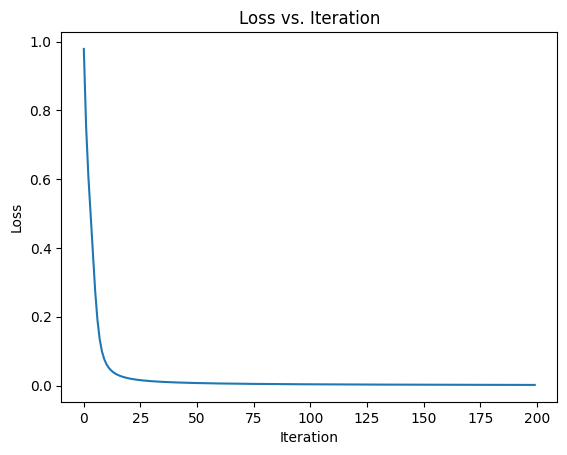

In [60]:
plot_losses(losses_mean)

##### Calculate outputs and Loss after last parameter adjustment

In [61]:
# calculate outputs and Loss after last parameter adjustment
ypred = [n(x) for x in xs]
loss_mean = sum((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred)) / len(
    ys
)  # low loss is better, perfect is loss = 0
ypred_data = [value.data for value in ypred]

print(f"\n-- Calculate outputs and Loss at end of iteration --")
print(f"ypred_data: {ypred_data}")
print(f"loss_mean: {loss_mean.data}\n\n")

# check calculation using forward pass function
print(f"Calculate outputs and Loss using optimized parameters")
yout, err, err_sq, loss_sum, loss_mean, w_mats, b_mats = forward_pass(
    n.layers, verbose=verbose
)


-- Calculate outputs and Loss at end of iteration --
ypred_data: [0.9649827611833902, -0.9484970394283715]
loss_mean: 0.001939380980991102


Calculate outputs and Loss using optimized parameters
--------------------------------------------------
Calculate Output of Layer: 0
weights (3, 2):
[[ 0.13223798 -0.39087635]
 [-0.09963127  0.55221771]
 [ 0.18993319  0.64305004]]

input (2, 2):
[[ 2.  3.]
 [ 1. -2.]]

weights_x_inputs (3, 2):
[[-0.12640038  1.17846666]
 [ 0.35295516 -1.40332925]
 [ 1.02291642 -0.71630052]]

bias (3, 1):
[[ 0.67656974]
 [ 0.70857745]
 [-0.5808349 ]]

weights_x_inputs_+_bias (3, 2):
[[ 0.55016936  1.85503639]
 [ 1.06153262 -0.69475179]
 [ 0.44208152 -1.29713542]]

Layer 0 Output = tanh(weights_x_inputs_+_bias) (3, 2):
[[ 0.50064713  0.95221802]
 [ 0.78624973 -0.60102596]
 [ 0.41536832 -0.8609839 ]]

--------------------------------------------------
Calculate Output of Layer: 1
weights (3, 3):
[[ 0.68237089  0.50080091  0.42372733]
 [-0.48245139  0.63858206  0.76

##### Compare changes in parameters after optimization

In [62]:
# save parameters
param_optmz = [p.data for p in n.parameters()]
param_comp = zip(param_org, param_optmz)

# print(f'i        param_new      param_org      param_dif')
print(f"i  param. optimized  param. orginal     param. dif")
for i, param_org_new in enumerate(param_comp):
    p_org = param_org_new[0]
    p_new = param_org_new[1]
    p_dif = p_new - p_org
    print(f"{i:<4} {p_new:>14.10f}  {p_org:>14.10f} {p_dif:>14.10f}")

i  param. optimized  param. orginal     param. dif
0      0.1322379849    0.2254331442  -0.0931951593
1     -0.3908763507   -0.3431568652  -0.0477194855
2      0.6765697373    0.7233275892  -0.0467578519
3     -0.0996312743    0.3241694317  -0.4238007060
4      0.5522177115    0.1048180101   0.4473997015
5      0.7085774537    0.8262920846  -0.1177146310
6      0.1899331871   -0.1600332838   0.3499664709
7      0.6430500429    0.2482066933   0.3948433496
8     -0.5808348966   -0.7872267197   0.2063918232
9      0.6823708917    0.8099966935  -0.1276258018
10     0.5008009060    0.4917733212   0.0090275848
11     0.4237273308    0.2692641527   0.1544631781
12    -0.4668090012   -0.3737440485  -0.0930649527
13    -0.4824513948   -0.4809386747  -0.0015127201
14     0.6385820612    0.5354929094   0.1030891518
15     0.7624053916    0.6756358354   0.0867695562
16    -0.2837107742   -0.3640755760   0.0803648018
17    -0.4128753744   -0.2144646644  -0.1984107100
18     0.8113128942    0.873928

#   &nbsp;
# - Build the Same Model Using PyTorch -

In [63]:
import torch
import torch.nn as nn


class MLP_torch(nn.Module):
    def __init__(self):
        super(MLP_torch, self).__init__()
        self.fc1 = nn.Linear(2, 3)
        self.fc2 = nn.Linear(3, 3)
        self.fc3 = nn.Linear(3, 1)

    def forward(self, x):
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = self.fc3(x)
        return x


model = MLP_torch()

# # inputs
# xs = [
#   [2.0, 3.0, -1.0],
#   [3.0, -1.0, 0.5]
# ]

# # desired targets
# ys = [1.0, -1.0]

# convert to tensor
t_xs = torch.tensor(xs)

# add a dimension to the index=1 position to target tensor,
#  e.g. change size from [2] to [2, 1]
t_ys = torch.unsqueeze(torch.tensor(ys), 1)

# # learning rate (i.e. step size)
# learning_rate = 0.05

losses = []
for epoch in range(200):
    # forward pass
    predictions = model(t_xs)

    # calculate loss
    loss = torch.nn.functional.mse_loss(predictions, t_ys)

    # remove loss gradient
    losses.append(loss.detach())

    # backpropagate
    loss.backward()

    # update weights
    for p in model.parameters():
        p.data -= learning_rate * p.grad.data

    # zero gradients
    for p in model.parameters():
        p.grad.data.zero_()

    if epoch % 10 == 0:
        print(f"Predictions:\n{predictions.detach()}")
        print(f"Epoch {epoch} loss: {loss}")

predictions = model(t_xs)
print("")
print(f"Predictions:\n{predictions.detach()}")
print(f"Loss: {loss}")

Predictions:
tensor([[-0.1384],
        [ 0.0757]])
Epoch 0 loss: 1.226522445678711
Predictions:
tensor([[ 0.4336],
        [-0.5660]])
Epoch 10 loss: 0.2546083331108093
Predictions:
tensor([[ 0.8722],
        [-0.8987]])
Epoch 20 loss: 0.013294853270053864
Predictions:
tensor([[ 0.9775],
        [-0.9819]])
Epoch 30 loss: 0.00041750192758627236
Predictions:
tensor([[ 0.9962],
        [-0.9969]])
Epoch 40 loss: 1.2004573363810778e-05
Predictions:
tensor([[ 0.9994],
        [-0.9995]])
Epoch 50 loss: 3.400821526611253e-07
Predictions:
tensor([[ 0.9999],
        [-0.9999]])
Epoch 60 loss: 9.606290873875878e-09
Predictions:
tensor([[ 1.0000],
        [-1.0000]])
Epoch 70 loss: 2.716618041631591e-10
Predictions:
tensor([[ 1.0000],
        [-1.0000]])
Epoch 80 loss: 7.426947945532447e-12
Predictions:
tensor([[ 1.0000],
        [-1.0000]])
Epoch 90 loss: 2.3092638912203256e-13
Predictions:
tensor([[ 1.0000],
        [-1.0000]])
Epoch 100 loss: 8.881784197001252e-14
Predictions:
tensor([[ 1.0

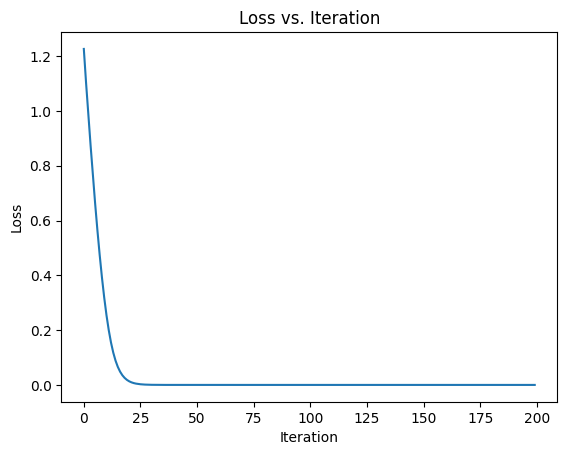

In [64]:
plot_losses(losses)

In [65]:
print(f"input xs:\n{xs}\n")
print(f"target ys:\n{ys}")
print("---------\n")


print(
    f"-- manual calculation of output for each layer from the optimized pytorch model --"
)
# l_items is a list of [weight matrix, bias matrix, ..., weight matrix, bias matrix]
l_items = list(model.parameters())
if len(l_items) % 2 == 0:  # True divisible by 2
    for i in range(0, len(l_items), 2):  # i: 0, 2, ..., len(l_items)-2
        if i == 0:  # use transposed t_xs as input only at the first time
            x0 = torch.clone(t_xs).detach()  # clone t_xs without autograd history
            input = torch.transpose(x0, 0, 1)  # columns of x0 becomes rows of input
        else:  # use previous output as input
            input = output

        w = l_items[i].detach()  # remove gradient
        b_ = l_items[i + 1].detach()  # remove gradient
        b = torch.clone(b_).detach()  # remove gradient
        bT = torch.unsqueeze(b, 1)  # add a dimension to index 1 position
        w_input = torch.matmul(w, input)
        w_input_bT = torch.add(w_input, bT)

        if i == len(l_items) - 2:  # skip tanh activation on output node
            output = w_input_bT
        else:
            output = torch.tanh(w_input_bT)

        print(f"layer: {i / 2},  i: {i}\n")
        print(f"w,  {w.shape}:\n{w}\n")
        print(f"input,  {input.shape}:\n{input}\n")
        print(f"w * input,  {w_input.shape}:\n{w_input}\n")
        print(f"bT,  {bT.shape}:\n{bT}\n")
        print(f"w * input + bT,  {w_input_bT.shape}:\n{w_input_bT}\n")
        print(f"output,  {output.shape}:\n{output}\n")
        print("")
else:
    raise ValueError(f"len(l_items) {len(l_items)} is not divisible by 2.")

input xs:
[[2.0, 1.0], [3.0, -2.0]]

target ys:
[1.0, -1.0]
---------

-- manual calculation of output for each layer from the optimized pytorch model --
layer: 0.0,  i: 0

w,  torch.Size([3, 2]):
tensor([[-0.2441, -0.5502],
        [ 0.0143,  0.5857],
        [-0.2587, -0.7848]])

input,  torch.Size([2, 2]):
tensor([[ 2.,  3.],
        [ 1., -2.]])

w * input,  torch.Size([3, 2]):
tensor([[-1.0384,  0.3679],
        [ 0.6144, -1.1284],
        [-1.3023,  0.7934]])

bT,  torch.Size([3, 1]):
tensor([[ 0.4976],
        [-0.1888],
        [ 0.3515]])

w * input + bT,  torch.Size([3, 2]):
tensor([[-0.5408,  0.8655],
        [ 0.4256, -1.3172],
        [-0.9507,  1.1450]])

output,  torch.Size([3, 2]):
tensor([[-0.4936,  0.6991],
        [ 0.4016, -0.8661],
        [-0.7401,  0.8161]])


layer: 1.0,  i: 2

w,  torch.Size([3, 3]):
tensor([[-0.2724, -0.0805,  0.1605],
        [ 0.3641, -0.3152,  0.5060],
        [ 0.1502,  0.4316, -0.8110]])

input,  torch.Size([3, 2]):
tensor([[-0.4936,  0.6

#   &nbsp;
# - Additional Information from PyTorch Model -

In [66]:
for module in model.modules():
    classname = module.__class__.__name__
    print(classname)
    # if 'Linear' in classname:
    #   # module = nn.Sequential(...)
    #   print(classname)

MLP_torch
Linear
Linear
Linear


In [67]:
t_xs.shape

torch.Size([2, 2])

In [68]:
from torchsummary import summary

summary(model, t_xs.shape)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                 [-1, 2, 3]               9
            Linear-2                 [-1, 2, 3]              12
            Linear-3                 [-1, 2, 1]               4
Total params: 25
Trainable params: 25
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [69]:
for name, param in model.named_parameters():
    param = param.detach()  # remove grad
    print(f"name: {name}")
    print(f"param: {param}")

    if name.find("weight") != -1:  # found
        print(f"weight matrix")
    elif name.find("bias") != -1:  # found
        print(f"bias matrix")
    else:
        raise ValueError(f"parameter name does not have 'weight' or 'bias' in the name")

    print("\n")

name: fc1.weight
param: tensor([[-0.2441, -0.5502],
        [ 0.0143,  0.5857],
        [-0.2587, -0.7848]])
weight matrix


name: fc1.bias
param: tensor([ 0.4976, -0.1888,  0.3515])
bias matrix


name: fc2.weight
param: tensor([[-0.2724, -0.0805,  0.1605],
        [ 0.3641, -0.3152,  0.5060],
        [ 0.1502,  0.4316, -0.8110]])
weight matrix


name: fc2.bias
param: tensor([0.5813, 0.0840, 0.3437])
bias matrix


name: fc3.weight
param: tensor([[-0.2810, -0.7749,  0.7515]])
weight matrix


name: fc3.bias
param: tensor([0.1437])
bias matrix


